In [1]:

import re
import numpy as np


def createDictionary(filename):
    priority_dict = {'HIGH': [], 'MID': [],'LOW':[]}
    # Open and read the file
    with open(filename, 'r') as file:
        # Read the entire content
        content = file.read()
        
        # Regular expression to match request patterns
        pattern = r"requestID : (test_\d+) - Priority : (\d+) - time : (\d+\.\d+)"
        
        # Find all matches
        matches = re.findall(pattern, content)
        
        # Process each match
        for request_id, priority, time in matches:
            if priority == '0':
                priority_dict['HIGH'].append(float(time))
            elif priority == '5':
                priority_dict['MID'].append(float(time))
            elif priority == '10':
                priority_dict['LOW'].append(float(time))
        return priority_dict

filename1 = '3mode_woLC_memoryCache.txt'
filename2 = '3mode_woLengthControl.txt'
filename3 = 'noPreemption_3mode_wLengthControl.txt'
filename4 = 'noPreemption_3mode_woLengthControl.txt'

# Print the result
target_wLengthControl = createDictionary(filename1)
target_woLengthControl = createDictionary(filename2)
base_wLengthControl = createDictionary(filename3)
base_woLengthControl = createDictionary(filename4)
print(target_wLengthControl['LOW'])
print(target_woLengthControl['LOW'])
print(base_wLengthControl['LOW'])
print(base_woLengthControl['LOW'])

[119003.629107, 119185.302721, 119369.103938, 119572.96276, 119770.911101, 119986.133432, 120196.373709, 120385.562884, 120599.218426, 120775.940916]
[118175.216263, 116844.179561, 115500.331218, 114148.932997, 112808.141915, 111462.968365, 110115.620216, 108761.455778, 107410.378048, 106065.146063]
[10180.197981, 10177.576009, 10173.724812, 10166.917786, 10180.376853, 10151.968285, 10145.97475, 10154.299824, 10147.015214, 10152.410933]
[9662.888952, 9669.374893, 9657.364159, 9658.876868, 9671.236398, 9661.938868, 9672.482872, 9658.99902, 9663.785413, 9667.629815]


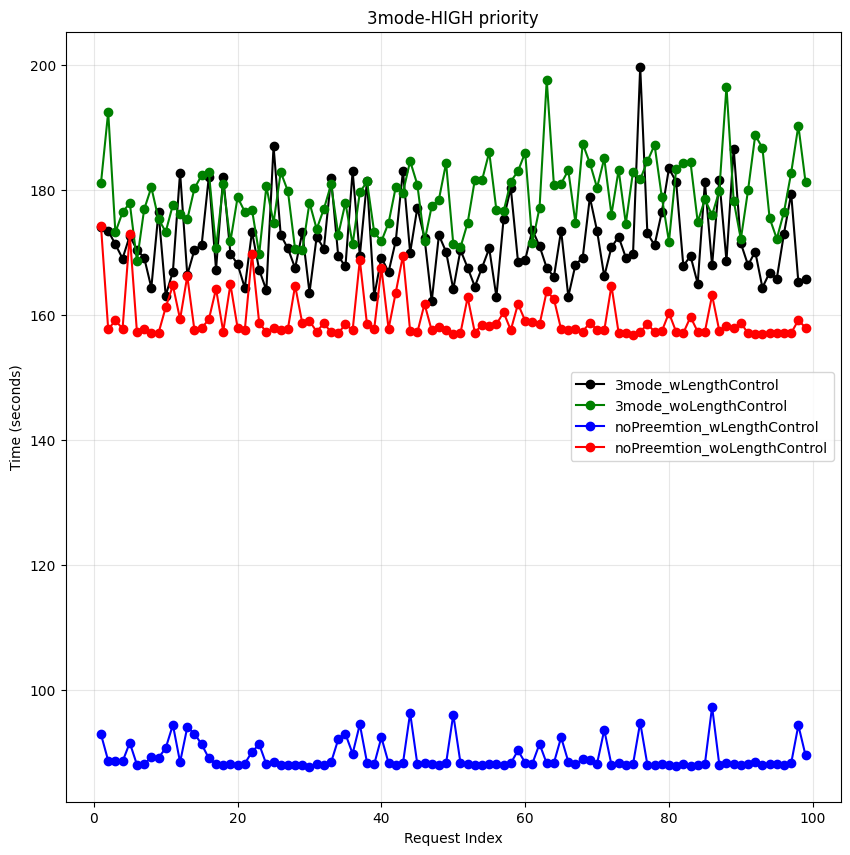

In [2]:
import matplotlib.pyplot as plt
target_wLengthControl_times = target_wLengthControl['HIGH'][1:]
target_woLengthControl_times = target_woLengthControl['HIGH'][1:]
base_wLengthControl_times = base_wLengthControl['HIGH'][1:]
base_woLengthControl_times = base_woLengthControl['HIGH'][1:]

# Creating x-axis values for each category
x_high = list(range(1, len(target_wLengthControl_times) + 1))

# Plotting the data
plt.figure(figsize=(10, 10))
if target_wLengthControl_times:
    plt.plot(x_high, target_wLengthControl_times, marker='o', color='black', label='3mode_wLengthControl')
if target_woLengthControl_times:
    plt.plot(x_high, target_woLengthControl_times, marker='o', color='green', label='3mode_woLengthControl')
if base_wLengthControl_times:
    plt.plot(x_high, base_wLengthControl_times, marker='o', color='blue', label='noPreemtion_wLengthControl')
if base_woLengthControl_times:
    plt.plot(x_high, base_woLengthControl_times, marker='o', color='red', label='noPreemtion_woLengthControl')


# Adding labels and styling
plt.title('3mode-HIGH priority')
plt.xlabel('Request Index')
plt.ylabel('Time (seconds)')
plt.grid(True, alpha=0.3)
plt.legend()

# Display the plot
plt.show()